# VARIANCE = How much are my numbers spread around the average?


In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = [10,20,30,40,100,48,1000]

print("Mean:", np.mean(data))


Mean: 178.28571428571428


In [5]:
print("Median:", np.median(data))   
print("Mode:", np.argmax(np.bincount(data)))

Median: 40.0
Mode: 10


In [6]:
import statistics as stats

print("Mean:", stats.mean(data))
print("Median:", stats.median(data))
print("Mode:", stats.mode(data))
print("Variance:", stats.variance(data))
print("Standard Deviation:", stats.stdev(data))

Mean: 178.28571428571428
Median: 40
Mode: 10
Variance: 132133.90476190476
Standard Deviation: 363.5022761440494


Yes. The **degrees of freedom (DoF)** in `statistics.variance()` is an important interview concept because Python's `statistics.variance()` calculates **sample variance**, not population variance.

Var(X)\=E(X2)−\[E(X)\]2Var(X) = E(X^2) - \[E(X)\]^2

Var(X)\=(1.4)2\=1.96Var(X)=(\\text{1.4})^2=\\text{1.96}Var(X)\=(1.4)2\=1.96

σ\\sigmaσ

σ\\sigmaσ

μ\-σ+σVar(X) ≈ 1.96

Give feedback

### Your code

```

from statistics import variance

data = [2, 4, 6, 8, 10]

print("Variance:", variance(data))
```

`statistics.variance(data)` uses the **sample variance formula**:

s2\=∑(xi−xˉ)2n−1s^2 = \\frac{\\sum (x\_i-\\bar{x})^2}{n-1}

The important part is:

> **Why `n - 1` instead of `n`?**

That `n - 1` is called the **degrees of freedom**.

* * *

# What is Degrees of Freedom?

In simple words:

> **Degrees of freedom = Number of independent values that are free to vary when estimating a parameter.**

For sample variance:

df\=n−1\\boxed{df = n-1}

where `n` is the number of observations.

* * *

## Let's understand with an example

Suppose we have:

```

data = [2, 4, 6]
```

There are:

```

n = 3
```

Calculate the sample mean:

xˉ\=2+4+63\=4\\bar{x} = \\frac{2+4+6}{3}=4

Now calculate deviations from the mean:

```

2 - 4 = -2
4 - 4 =  0
6 - 4 =  2
```

Notice something interesting:

```

-2 + 0 + 2 = 0
```

Once we know the mean, the deviations are **not completely independent**.

If we know two deviations:

```

-2
 0
```

we already know the third must be:

```

+2
```

because the deviations from the sample mean must add up to zero.

Therefore:

```

3 observations
       ↓
1 degree is constrained
       ↓
3 - 1 = 2 degrees of freedom
```

* * *

# Why `n - 1`?

When calculating **sample variance**, we first estimate the population mean using the sample itself.

That estimation uses up **one degree of freedom**.

Therefore:

df\=n−1df = n-1

and:

s2\=∑(xi−xˉ)2n−1s^2 = \\frac{\\sum (x\_i-\\bar{x})^2}{n-1}

* * *

# Example with `statistics.variance()`

```

from statistics import variance

data = [2, 4, 6]

print("Variance:", variance(data))
```

Let's calculate manually.

### Step 1: Mean

xˉ\=4\\bar{x}=4

### Step 2: Squared deviations

```

(2 - 4)² = 4
(4 - 4)² = 0
(6 - 4)² = 4
```

Sum:

4+0+4\=84+0+4=8

### Step 3: Divide by `n - 1`

There are 3 observations:

n−1\=3−1\=2n-1=3-1=2

Therefore:

Sample Variance\=82\=4Sample\\ Variance = \\frac{8}{2}=4

So:

```

statistics.variance(data)
→ 4
```

* * *

# Population Variance vs Sample Variance

This is **very important for interviews**.

### Population Variance

When you have the **entire population**:

σ2\=∑(xi−μ)2N\\sigma^2 = \\frac{\\sum (x\_i-\\mu)^2}{N}

Divide by:

```

N
```

### Sample Variance

When you have a **sample from the population**:

s2\=∑(xi−xˉ)2n−1s^2 = \\frac{\\sum (x\_i-\\bar{x})^2}{n-1}

Divide by:

```

n - 1
```

### Python

```

from statistics import variance, pvariance

data = [2, 4, 6]

print(variance(data))    # Sample variance
print(pvariance(data))   # Population variance
```

Output:

```

4
2.6666666666666665
```

Because:

Sample Variance\=83−1\=4Sample\\ Variance = \\frac{8}{3-1}=4

while:

Population Variance\=83\=2.67Population\\ Variance = \\frac{8}{3}=2.67

* * *

# Why do we use `n-1`?

The deeper reason is that **sample variance with `n-1` provides an unbiased estimator of the population variance**.

If we divided by `n` while using the **sample mean**, we would tend to **underestimate the population variance**.

Using `n-1` corrects for that bias.

This is commonly called **Bessel's correction**.

> **Bessel's correction = replacing `n` with `n-1` when estimating population variance from a sample.**

* * *

# Easy Way to Remember

```

Entire Population
       ↓
Population Variance
       ↓
Divide by N
```

```

Sample
  ↓
Sample Variance
  ↓
Divide by n - 1
```

### Python

```

statistics.pvariance(data)
```

→ Population variance

```

statistics.variance(data)
```

→ Sample variance

* * *

# ⭐ Interview Questions

### Q1. What are degrees of freedom?

**Answer:**

> Degrees of freedom represent the number of independent values that are free to vary when estimating a statistical parameter.

* * *

### Q2. What is the degrees of freedom for sample variance?

**Answer:**

> For a sample of size `n`, the degrees of freedom are `n - 1`.

* * *

### Q3. Why do we use `n-1` instead of `n` for sample variance?

**Answer:**

> Because the sample mean is estimated from the same data, one degree of freedom is lost. Dividing by `n-1`, known as Bessel's correction, gives an unbiased estimate of the population variance.

* * *

### Q4. What does `statistics.variance()` calculate?

**Answer:**

> `statistics.variance()` calculates **sample variance** and uses `n-1` as the denominator.

* * *

### Q5. What does `statistics.pvariance()` calculate?

**Answer:**

> `statistics.pvariance()` calculates **population variance** and uses `N` as the denominator.

* * *

### Q6. What is Bessel's correction?

**Answer:**

> Bessel's correction is the use of `n-1` instead of `n` when calculating sample variance to obtain an unbiased estimate of the population variance.

* * *

### ⭐ One-line interview answer

> **`statistics.variance(data)` calculates sample variance, so it uses `n-1` degrees of freedom because one degree of freedom is lost when the sample mean is estimated from the data.**

# (1/n) vs (1/(n-1))

In [7]:
import numpy as np

np.random.seed(88) # Generate the same random numbers

In [8]:
population = np.random.normal(loc=50, scale=10, size=100000) 

# normal distribution
# loc --> means centre should be 50 i.e genrate nuber which is arond 50 --> 50
# scale --> SD -> 10

''' 
np.random.normal(
       ↓
  "Give me random numbers"
       ↓
  loc = center
  scale = spread
  size = how many

  loc = WHERE the numbers are centered
scale = HOW SPREAD OUT they are
size = HOW MANY numbers I want
)

'''

' \nnp.random.normal(\n       ↓\n  "Give me random numbers"\n       ↓\n  loc = center\n  scale = spread\n  size = how many\n\n  loc = WHERE the numbers are centered\nscale = HOW SPREAD OUT they are\nsize = HOW MANY numbers I want\n)\n\n'

In [9]:
population.shape

(100000,)

In [10]:
population[0:10]

array([51.06884304, 72.05815242, 59.56562693, 50.68411101, 60.68513815,
       59.97182642, 40.68452085, 57.30430493, 48.28786308, 37.1130882 ])

In [11]:
true_variance = np.var(population) # 1/n
print("True Population Variance:", true_variance)

True Population Variance: 99.76566581263683


In [12]:
# For SImulation we are creating 1000 samples of size 5 from the population and calculating the variance for each sample using three different formulas: 1/n, 1/(n-1), and 1/(n-2).
n_samples = 1000
sample_size = 5

var_using_n = []
var_using_n_minus_1 = []
var_using_n_minus_2 = []

In [13]:
for _ in range(n_samples):# if we dont have to use the variable we can use _ in place of variable name.
    sample = np.random.choice(population, size=sample_size, replace=False) # HEre we are choosing 5 random samples from the population without replacement.

    var_n = np.var(sample) #this will return the list of variances for each sample using 1/n formula.
    var_n1 = np.var(sample, ddof=1) #code fro n-1 #this will return the list of variances for each sample using 1/n-1 formula.
    var_n2 = np.var(sample, ddof=2) #this will return the list of variances for each sample using 1/n-2 formula.

    var_using_n.append(var_n)
    var_using_n_minus_1.append(var_n1)
    var_using_n_minus_2.append(var_n2)

In [14]:
# here we are calculating the mean of the variances calculated using the three different formulas across all 1000 samples. This will give us an idea of how each method performs in estimating the population variance.
# calculating the avg varaive from the list of variances calculated using the three different formulas across all 1000 samples. This will give us an idea of how each method performs in estimating the population variance.
avg_var_n = np.mean(var_using_n)
avg_var_n1 = np.mean(var_using_n_minus_1)
avg_var_n2 = np.mean(var_using_n_minus_2)

In [15]:
print("Average variance using n      :", avg_var_n)
print("Average variance using n-1   :", avg_var_n1)
print("Average variance using n-2   :", avg_var_n2)

Average variance using n      : 79.0891296608315
Average variance using n-1   : 98.86141207603939
Average variance using n-2   : 131.81521610138583


In [16]:
# problem : sample_mean < population_mean

# sample_mean == population_mean
# sample_mean > population_mean
# sample_mean ~ population_mean

In [17]:
# bessels Correction - Divide by n-1 instead of n, inflate the result just enugh to cancel out the underestmate.

In [18]:
# Why we choose n-1 instead of n-2 for Bessel's correction?
# If we know the mean amd we wamt to calculate total number of person them n-1 person are free to set the valu and last value is the forced to be set to make the mean correct. So we have n-1 free values and 1 forced value. So we divide by n-1 instead of n-2.

In [19]:
# Percentile --> what percentage of the data is below a certain value. For example, if you are in the 90th percentile, it means you scored better than 90% of the people who took the test. or 90% ofpeople score less than you
# percentile  is not the same as percentage. Percentage is a part of a whole, while percentile is a rank or position in a distribution.Percentile never tells the actual value, it only tells the relative position of a value in a distribution. For example, if you are in the 90th percentile, it means you scored better than 90% of the people who took the test. or 90% ofpeople score less than you

# Percentile

In [20]:
data = [10,20,30, 40, 50]

In [21]:
np.percentile(data, 50) # what value is my 50%tile

np.float64(30.0)

In [22]:
np.percentile(data, 100) # what value is my 100%tile

np.float64(50.0)

In [23]:
print(np.percentile(data, 80))

42.0


Nearest Rank Formula

If you have N values and want the Pth percentile:

rank = p/100 * n

p= percwntile 
if we get ran as 2 then second posiotion in the series it the percentile if the vlue is in decimal then do the cieling oeration i.e chose the value which is nearest  example for 3.2 then selecte 3 , for 3.9 select 4
	​


Linear Interpolation

L = p/100 * (n-1) +1

after getting the L

value(floor(L))+ [ceil(L)-L]

get this in chat gpt


PLease watc the recording for this classs april 4 for IQR 15 min before 3 hrs to complete
IQR gives majority of the data where as as std deviation is ussed to get th spred which is not correct because it is calculated based on the mean snd anything tyhag uses mean get affected by the etreme values , but if we want the some kind of range to perform statusitics we need to remove the extreme vslue and do the analysiuis on th majority of the data snd we can find ,ajority of data using IQR

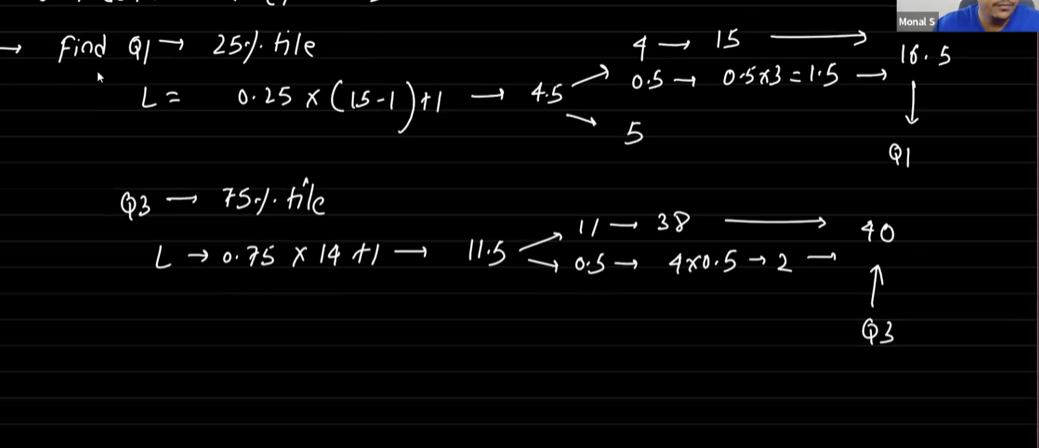

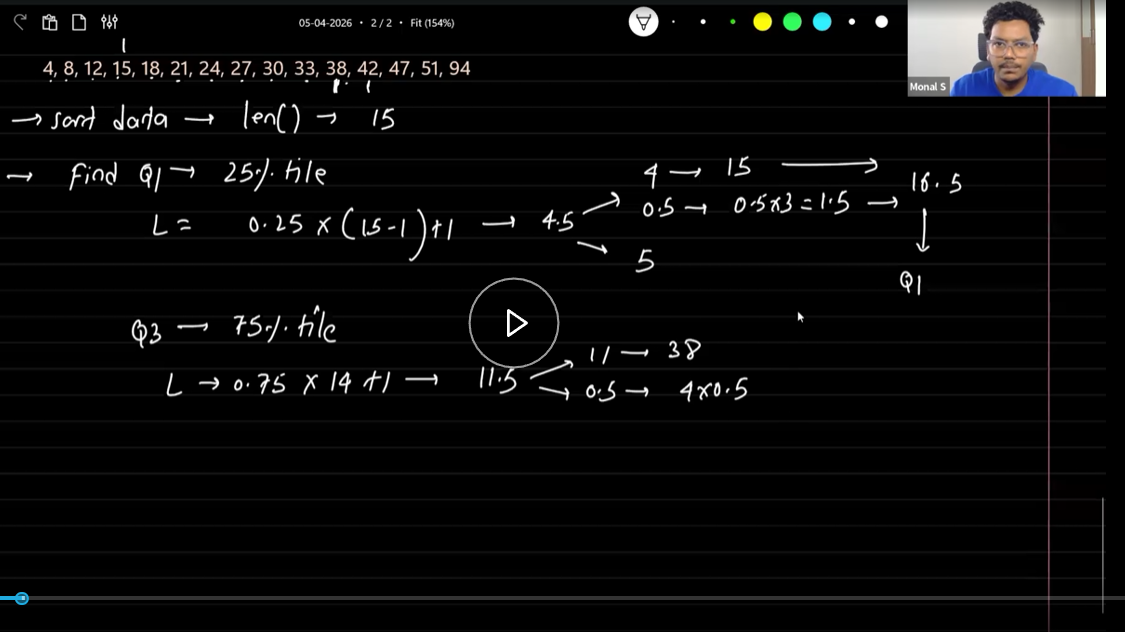

What is IQR?

IQR tells us how spread out the middle 50% of our data is.

Think of a classroom with 100 students.

Instead of worrying about the very lowest 25 students and very highest 25 students, IQR looks at the middle 50 students.

Lowest 25% |     Middle 50%      | Highest 25%
-----------|---------------------|------------
     Q1    |       IQR           |     Q3

The formula is:

$$ \boxed{IQR = Q3 - Q1} $$

Where:

Q1 = 25th percentile
Q2 = 50th percentile = Median
Q3 = 75th percentile
Let's take an example

Suppose we have:

10, 20, 30, 40, 50, 60, 70, 80

We want to understand the middle 50%.

Imagine:

10  20 | 30  40  50  60 | 70  80
        ↑                 ↑
        Q1                Q3

Suppose:

Q1 = 25
Q3 = 65

Then:

$$ IQR = Q3-Q1 $$ $$ IQR=65-25 $$ $$ \boxed{IQR=40} $$

So the middle 50% of the data is spread across 40 units.

Why do we use Q1 and Q3?

Divide the data into four parts:

        25%       25%       25%       25%
     |--------|---------|---------|---------|
     Minimum   Q1        Q2        Q3      Maximum
                        Median

So:

Q1 → 25% of data is below it
Q2 → 50% of data is below it
Q3 → 75% of data is below it

Therefore:

Q1 → Q3

contains the middle 50%.

And the distance between them is:

$$ \boxed{IQR=Q3-Q1} $$
⭐ Why is IQR useful?

The biggest advantage of IQR is:

IQR is not strongly affected by outliers.

Consider:

10, 20, 30, 40, 50, 60, 70

Now suppose someone adds a huge value:

10, 20, 30, 40, 50, 60, 7000

The 7000 is an outlier.

It can have a huge effect on the mean and range.

But IQR focuses on the middle 50%, so the outlier has little or no effect on it.

That's why:

$$ \boxed{\text{IQR is a robust measure of spread}} $$
IQR vs Range

This is important for interviews.

Range
$$ Range = Maximum-Minimum $$

It considers the extreme values.

10 ------------------------------ 7000
↑                                    ↑
Minimum                           Maximum

So an outlier can make the range extremely large.

IQR

IQR only looks between Q1 and Q3:

10   |---- Q1 ===== Middle 50% ===== Q3 ----|   7000

Therefore it is much less affected by extreme values.

Measure	What it measures	Effect of outliers
Range	Entire spread	❌ Highly affected
IQR	Middle 50% spread	✅ Less affected
Standard Deviation	Spread around mean	❌ Affected
🧠 IQR and Box Plot

IQR is also very important for box plots.

        Q1        Median       Q3
         ↓           ↓           ↓
────────[===========|===========]────────
         <--------- IQR -------->

The box itself represents the IQR.

So when you see a box plot:

The length of the box = IQR

🚨 IQR for detecting outliers

There is another important formula:

$$ \boxed{Lower\ Bound=Q1-1.5(IQR)} $$ $$ \boxed{Upper\ Bound=Q3+1.5(IQR)} $$

Values outside these boundaries are commonly treated as potential outliers.

Example

Suppose:

Q1 = 20
Q3 = 60

Then:

$$ IQR=60-20=40 $$

Lower bound:

$$ 20-1.5(40)=20-60=-40 $$

Upper bound:

$$ 60+1.5(40)=60+60=120 $$

Therefore:

Values < -40  → potential outliers
Values > 120  → potential outliers
🎯 Interview answer

If interviewer asks:

"What is IQR?"

Say:

IQR, or Interquartile Range, measures the spread of the middle 50% of the data. It is calculated as Q3 minus Q1 and is relatively resistant to outliers.

$$ \boxed{IQR=Q3-Q1} $$
Remember these 4 things
Q1 = 25th percentile
Q2 = 50th percentile = Median
Q3 = 75th percentile

IQR = Q3 - Q1

IQR = spread of middle 50%

IQR is relatively resistant to outliers

Easy memory trick:
👉 "IQR = Inside the middle Quarter Range."

Data:
4, 8, 12, 15, 18, 21, 24, 27, 30, 33, 38, 42, 47, 51, 94

n = 15
Q1 = 25th percentile

L = (25/100)(15-1) + 1
  = 0.25 × 14 + 1
  = 4.5

Position 4 = 15
Position 5 = 18

Decimal part = 0.5

Distance = 18 - 15
         = 3

Move = 0.5 × 3
     = 1.5

Q1 = 15 + 1.5
   = 16.5